# Topología en Forecasting de Series Temporales
## Sesión Introductoria 

**Objetivo:** Entender cómo la homología persistente puede ayudar a predecir el futuro de una serie temporal, usando señales sintéticas que nos permitan visualizar cada paso del proceso.

**En esta sesión veremos:**
1. Generar señales sintéticas con diferentes comportamientos
2. Aplicar ventanas deslizantes (Sliding Window)
3. Usar embedding de Takens para convertir series en nubes de puntos
4. Extraer características topológicas (persistencia)
5. Construir un pipeline de forecasting que combine TDA + Random Forest
6. Comparar resultados visualmente

---
**Autor:** Dr. Hugo García Tecocoatzi  


In [1]:
# ============================================================
# Librerías
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import FeatureUnion
from functools import partial

# giotto-tda
from gtda.time_series import SlidingWindow, TakensEmbedding, SingleTakensEmbedding, Labeller
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Amplitude, PersistenceEntropy
from gtda.pipeline import make_pipeline

# Configuración de gráficos
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Librerías cargadas correctamente")
print(f"NumPy: {np.__version__}")

✅ Librerías cargadas correctamente
NumPy: 1.26.4


## 1. Generación de Señales Sintéticas

Para entender cómo funciona el forecasting con topología, crearemos **tres señales sintéticas** con diferentes comportamientos:

- **Señal A:** Seno puro (periódica, fácil de predecir)
- **Señal B:** Seno con ruido (periódica + ruido, más realista)
- **Señal C:** Seno con cambio de frecuencia abruptamente

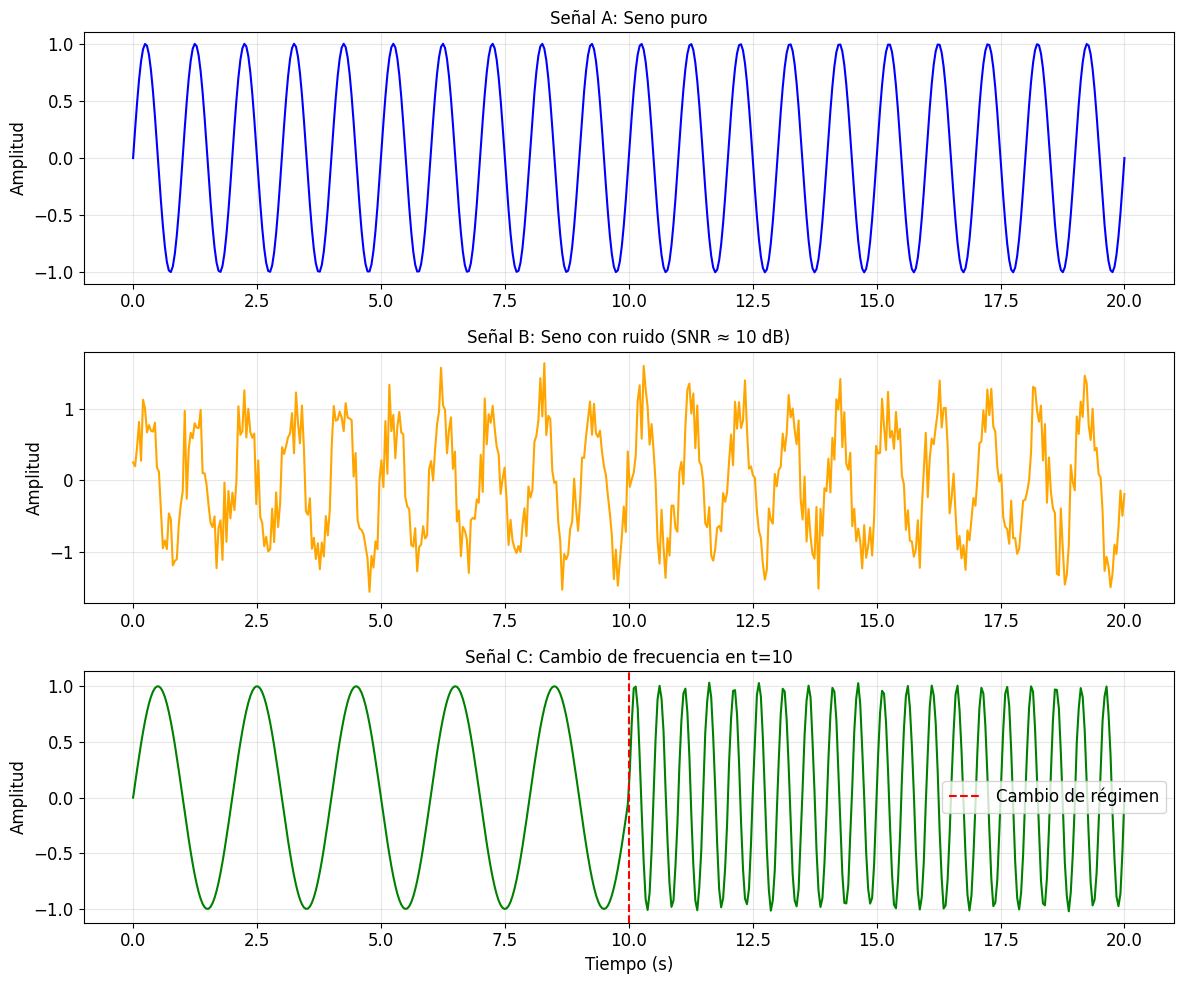

In [2]:
# ============================================================
# GENERAR SEÑALES SINTÉTICAS
# ============================================================

# Parámetros 
n_points = 500
t = np.linspace(0, 20, n_points)

# Señal A: Seno puro (frecuencia = 1 Hz)
signal_A = np.sin(2 * np.pi * 1 * t)

# Señal B: Seno puro + ruido
noise = np.random.normal(0, 0.3, n_points)
signal_B = np.sin(2 * np.pi * 1 * t) + noise

# Señal C: Cambio de frecuencia en t=10 (frecuencia 0.5 → 2 Hz)
signal_C = np.zeros(n_points)
mask1 = t < 10
mask2 = t >= 10
signal_C[mask1] = np.sin(2 * np.pi * 0.5 * t[mask1])
signal_C[mask2] = np.sin(2 * np.pi * 2 * t[mask2]) + 0.2 * np.random.normal(0, 0.1, np.sum(mask2))

# Visualización
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(t, signal_A, 'b-', linewidth=1.5)
axes[0].set_title('Señal A: Seno puro', fontsize=12)
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, signal_B, 'orange', linewidth=1.5)
axes[1].set_title('Señal B: Seno con ruido (SNR ≈ 10 dB)', fontsize=12)
axes[1].set_ylabel('Amplitud')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, signal_C, 'green', linewidth=1.5)
axes[2].axvline(x=10, color='red', linestyle='--', label='Cambio de régimen')
axes[2].set_title('Señal C: Cambio de frecuencia en t=10', fontsize=12)
axes[2].set_xlabel('Tiempo (s)')
axes[2].set_ylabel('Amplitud')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Preguntas

**Observa las tres señales generadas:**

1. ¿Cuál señal crees que será más fácil de predecir? ¿Por qué?
2. ¿Qué desafíos presenta la Señal C para un modelo predictivo tradicional?
3. ¿Cómo crees que la topología podría ayudar en la Señal B?







## 2. Sliding Window

El primer paso para hacer forecasting es dividir la serie temporal en **ventanas** que servirán como ejemplos de entrenamiento.

- **window_size:** cuántos puntos pasados usamos para predecir
- **stride:** cada cuántos puntos tomamos una nueva ventana
- **target:** qué queremos predecir (el siguiente punto en la serie de tiempo)

Señal original: (500,)
Ventanas generadas: (93, 40, 1)
Targets: (93,)
Cada ventana contiene 40 puntos consecutivos


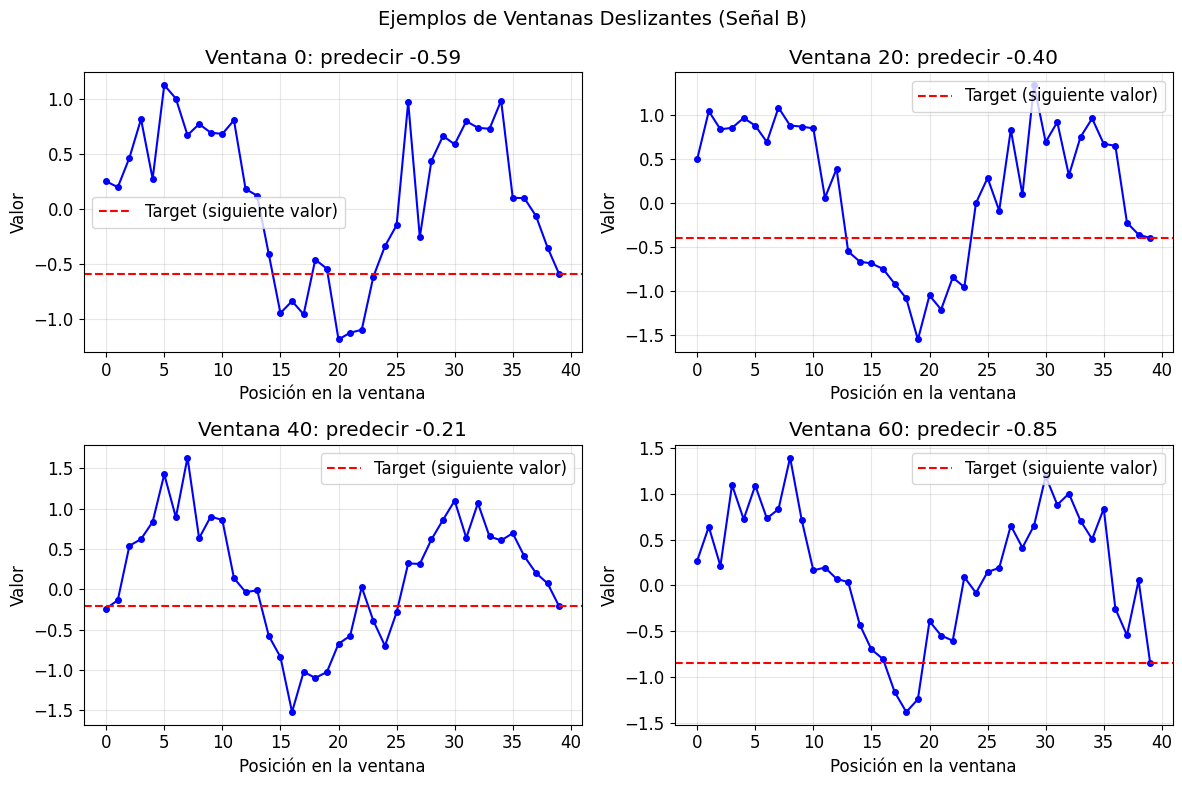

In [3]:
# ============================================================
# Sliding windows
# ============================================================

from gtda.time_series import SlidingWindow

window_size = 40  # Usamos 40 puntos para predecir
stride = 5

# Aplicar SlidingWindow
SW = SlidingWindow(size=window_size, stride=stride)

# Usar la Señal B como ejemplo
X_windows, y_target = SW.fit_transform_resample(signal_B.reshape(-1, 1), signal_B)

print(f"Señal original: {signal_B.shape}")
print(f"Ventanas generadas: {X_windows.shape}")
print(f"Targets: {y_target.shape}")
print(f"Cada ventana contiene {window_size} puntos consecutivos")

# Visualizar algunas ventanas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ventanas_mostrar = [0, 20, 40, 60]
for idx, ax in enumerate(axes.flat):
    if idx < len(ventanas_mostrar):
        w = ventanas_mostrar[idx]
        ax.plot(X_windows[w], 'b-o', markersize=4, linewidth=1.5)
        ax.axhline(y=y_target[w], color='red', linestyle='--', label='Target (siguiente valor)')
        ax.set_title(f'Ventana {w}: predecir {y_target[w]:.2f}')
        ax.set_xlabel('Posición en la ventana')
        ax.set_ylabel('Valor')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.suptitle('Ejemplos de Ventanas Deslizantes (Señal B)', fontsize=14)
plt.tight_layout()
plt.show()

### Preguntas

**Analiza las ventanas mostradas:**

1. ¿Qué relación observas entre la forma de la ventana y el target (línea roja)?
2. ¿Por qué es importante no usar información del futuro al crear las ventanas?
3. ¿Qué pasa si usamos un stride muy grande? ¿Y muy pequeño?






## 3. Embedding de Takens

El **embedding de Takens** convierte una serie temporal en una **nube de puntos** en un espacio de mayor dimensión.

**Parámetros:**
- **dimension (d):** número de retardos (cuántos puntos pasados usamos)
- **time_delay (τ):** separación entre retardos

**Recordemos:** Una señal periódica se convierte en un **círculo** o **espiral** en el espacio de embedding. ¡La topología puede detectar esto!

Embedding Señal A: (484, 3)
Embedding Señal B: (484, 3)
Embedding Señal C: (484, 3)


/tmp/ipykernel_16550/2282105558.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


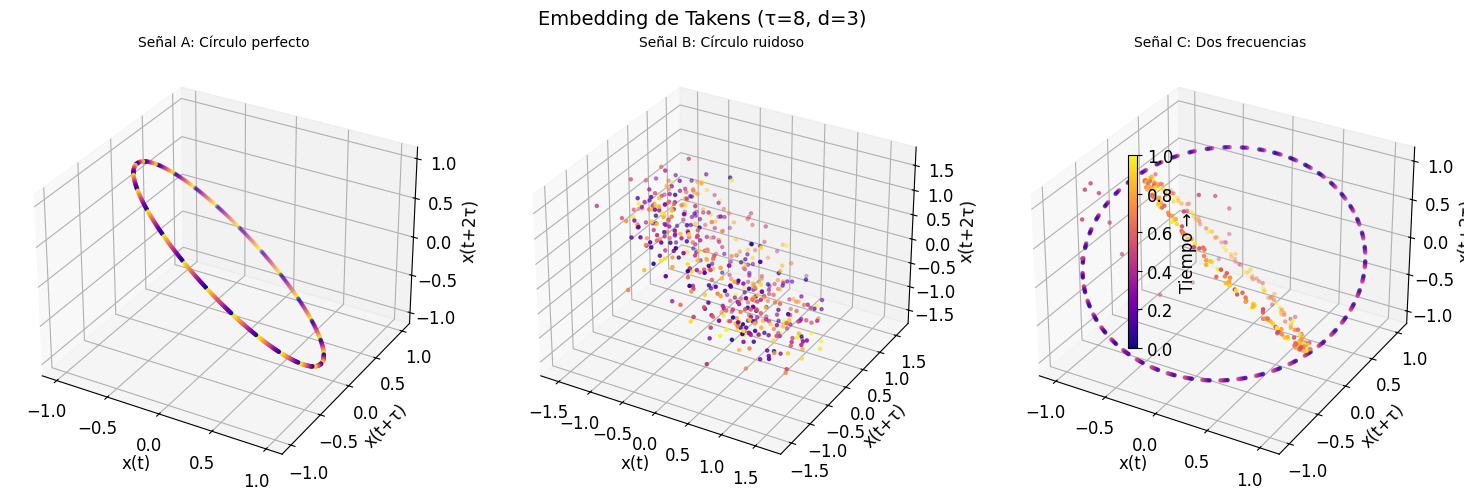

In [4]:
# ============================================================
# EMBEDDING DE TAKENS EN 3D
# ============================================================

from gtda.time_series import SingleTakensEmbedding

# Parámetros del embedding
dimension = 3  # Queremos ver en 3D
time_delay = 8

# Aplicar a las tres señales
STE = SingleTakensEmbedding(
    parameters_type="fixed",
    dimension=dimension,
    time_delay=time_delay
)

# Embedding de cada señal
embedding_A = STE.fit_transform(signal_A)
embedding_B = STE.fit_transform(signal_B)
embedding_C = STE.fit_transform(signal_C)

print(f"Embedding Señal A: {embedding_A.shape}")
print(f"Embedding Señal B: {embedding_B.shape}")
print(f"Embedding Señal C: {embedding_C.shape}")

# Visualización 3D
fig = plt.figure(figsize=(15, 5))

# Señal A
ax1 = fig.add_subplot(131, projection='3d')
sc1 = ax1.scatter(embedding_A[:, 0], embedding_A[:, 1], embedding_A[:, 2],
                  c=np.linspace(0, 1, len(embedding_A)), cmap='plasma', s=5)
ax1.set_title('Señal A: Círculo perfecto', fontsize=10)
ax1.set_xlabel('x(t)')
ax1.set_ylabel('x(t+τ)')
ax1.set_zlabel('x(t+2τ)')

# Señal B
ax2 = fig.add_subplot(132, projection='3d')
sc2 = ax2.scatter(embedding_B[:, 0], embedding_B[:, 1], embedding_B[:, 2],
                  c=np.linspace(0, 1, len(embedding_B)), cmap='plasma', s=5)
ax2.set_title('Señal B: Círculo ruidoso', fontsize=10)
ax2.set_xlabel('x(t)')
ax2.set_ylabel('x(t+τ)')
ax2.set_zlabel('x(t+2τ)')

# Señal C
ax3 = fig.add_subplot(133, projection='3d')
sc3 = ax3.scatter(embedding_C[:, 0], embedding_C[:, 1], embedding_C[:, 2],
                  c=np.linspace(0, 1, len(embedding_C)), cmap='plasma', s=5)
ax3.set_title('Señal C: Dos frecuencias', fontsize=10)
ax3.set_xlabel('x(t)')
ax3.set_ylabel('x(t+τ)')
ax3.set_zlabel('x(t+2τ)')

plt.suptitle('Embedding de Takens (τ=8, d=3)', fontsize=14)
plt.colorbar(sc3, ax=[ax1, ax2, ax3], label='Tiempo →', shrink=0.5)
plt.tight_layout()
plt.show()

### Pregunta 

**Observa los embeddings 3D:**

1. ¿Qué forma geométrica observas en la Señal A? ¿Por qué?
2. ¿Cómo afecta el ruido en la Señal B? ¿La forma sigue siendo reconocible?
3. ¿Qué observas en la Señal C? ¿Por qué aparece esa estructura?
4. ¿Qué parámetros (τ y d) crees que son óptimos para detectar periodicidad?






## 4. Homología Persistente

La homología persistente **cuantifica la topología** de una nube de puntos.

- **H₀:** Número de componentes conexas
- **H₁:** Número de lazos o agujeros

**Recuerda:** Una señal periódica tiene **H₁ = 1** (forma un círculo después del embedding). El ruido tiene **H₁ = 0**.

✅ Diagramas calculados
Diagramas A shape: (484, 3) (filas: [birth, death, homology_dim])
Diagramas B shape: (688, 3)
Diagramas C shape: (496, 3)

Señal A: Seno puro:
   Puntos H₁ encontrados: 1
      Punto 1: birth=0.0322, death=2.1115, persistence=2.0794

Señal B: Seno con ruido:
   Puntos H₁ encontrados: 205
      Punto 1: birth=0.7269, death=0.7283, persistence=0.0014
      Punto 2: birth=0.6514, death=0.7033, persistence=0.0518
      Punto 3: birth=0.5647, death=0.6384, persistence=0.0737
      Punto 4: birth=0.5608, death=0.5680, persistence=0.0071
      Punto 5: birth=0.5084, death=0.5654, persistence=0.0569
      Punto 6: birth=0.4947, death=0.5346, persistence=0.0398
      Punto 7: birth=0.4849, death=0.5361, persistence=0.0513
      Punto 8: birth=0.4817, death=0.4943, persistence=0.0125
      Punto 9: birth=0.4716, death=0.4880, persistence=0.0164
      Punto 10: birth=0.4541, death=0.5295, persistence=0.0754
      Punto 11: birth=0.4428, death=0.4696, persistence=0.0268
    

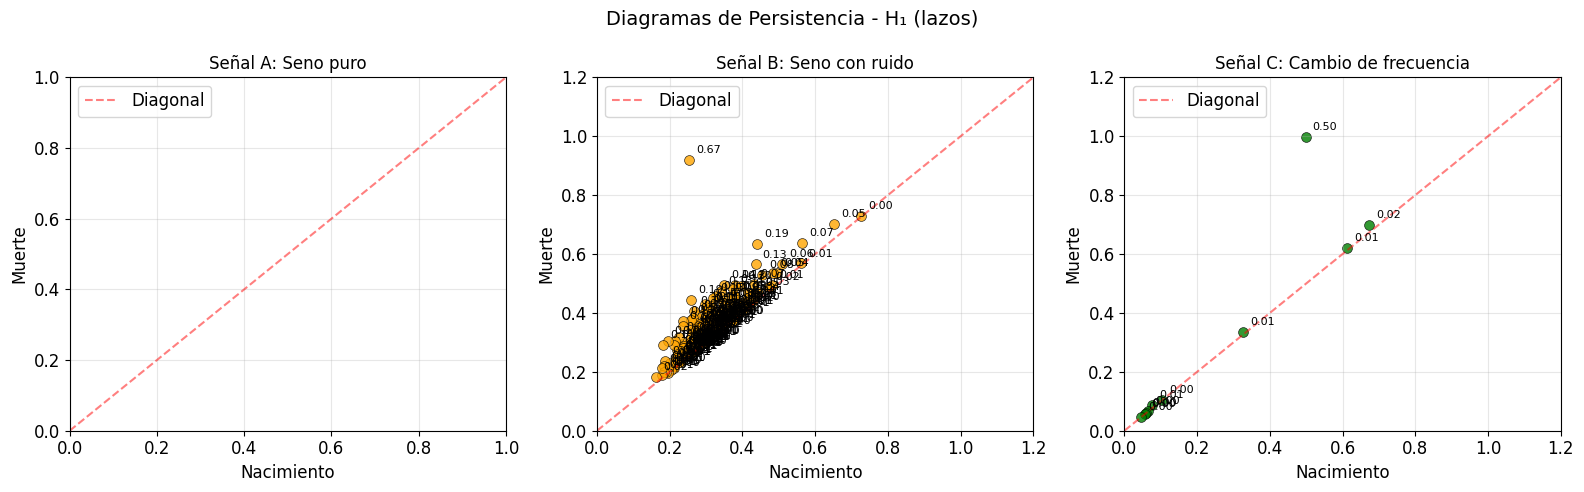


📊 PERSISTENCIA MÁXIMA EN H₁
Señal A (seno puro):               2.0794
Señal B (seno con ruido):           0.6669
Señal C (cambio de régimen):        1.4551

💡 INTERPRETACIÓN:
----------------------------------------
✅ Señal A: Persistencia = 2.079 → Estructura circular detectada
   (El punto puede estar cerca de la diagonal por la perfección del círculo)
✅ Señal B: Persistencia = 0.667 → Periodicidad detectable pese al ruido
----------------------------------------

📋 Detalle de persistencia por punto:
   Señal A: [2.07938175]
   Señal B: [0.00140524 0.05181658 0.07369703 0.00713372 0.05693066 0.03984621
 0.05126813 0.01253903 0.01636839 0.07540399 0.0267626  0.193584
 0.12825942 0.06654951 0.01385087 0.03612134 0.05355367 0.00412181
 0.01318195 0.02533391 0.03546494 0.01761863 0.00801149 0.03008214
 0.09634489 0.01400957 0.03244966 0.01105967 0.03357163 0.07824323
 0.07550839 0.02332515 0.11797699 0.10737497 0.00194171 0.0037877
 0.062639   0.04109946 0.02070573 0.09182024 0.01165271

In [5]:
# ============================================================
# CÁLCULO DE DIAGRAMAS DE PERSISTENCIA
# ============================================================

from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude
import warnings
warnings.filterwarnings('ignore')

# Parámetros
homology_dimensions = [0, 1]  # Calculamos H₀ y H₁

VR = VietorisRipsPersistence(
    metric="euclidean",
    homology_dimensions=homology_dimensions,
    n_jobs=-1,
    collapse_edges=True  # Mejora el rendimiento
)

# Calcular diagramas
diagrams_A = VR.fit_transform([embedding_A])[0]
diagrams_B = VR.fit_transform([embedding_B])[0]
diagrams_C = VR.fit_transform([embedding_C])[0]

print("✅ Diagramas calculados")
print(f"Diagramas A shape: {diagrams_A.shape} (filas: [birth, death, homology_dim])")
print(f"Diagramas B shape: {diagrams_B.shape}")
print(f"Diagramas C shape: {diagrams_C.shape}")

# Función para filtrar y graficar H₁
def plot_h1_diagram(diagrams, ax, title, color, xlim_max=1.5):
    """Grafica el diagrama de persistencia para H₁"""
    mask = diagrams[:, 2] == 1
    if np.any(mask):
        births = diagrams[mask, 0]
        deaths = diagrams[mask, 1]
        persistences = deaths - births
        
        # Mostrar información
        print(f"\n{title}:")
        print(f"   Puntos H₁ encontrados: {len(births)}")
        for i, (b, d, p) in enumerate(zip(births, deaths, persistences)):
            print(f"      Punto {i+1}: birth={b:.4f}, death={d:.4f}, persistence={p:.4f}")
        
        # Graficar
        ax.scatter(births, deaths, c=color, s=50, alpha=0.8, edgecolors='black', linewidth=0.5)
        
        # Etiquetar puntos con su persistencia
        for i, (b, d, p) in enumerate(zip(births, deaths, persistences)):
            ax.annotate(f'{p:.2f}', (b, d), xytext=(5, 5), textcoords='offset points', fontsize=8)
    else:
        print(f"\n{title}: No se encontraron puntos H₁")
        ax.text(0.5, 0.5, 'Sin puntos H₁', transform=ax.transAxes, 
                ha='center', va='center', fontsize=12, color='gray')
    
    ax.plot([0, xlim_max], [0, xlim_max], 'r--', alpha=0.5, label='Diagonal')
    ax.set_xlabel('Nacimiento')
    ax.set_ylabel('Muerte')
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, xlim_max)
    ax.set_ylim(0, xlim_max)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Crear figura
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Graficar con diferentes límites según la señal
plot_h1_diagram(diagrams_A, axes[0], 'Señal A: Seno puro', 'blue', xlim_max=1.0)
plot_h1_diagram(diagrams_B, axes[1], 'Señal B: Seno con ruido', 'orange', xlim_max=1.2)
plot_h1_diagram(diagrams_C, axes[2], 'Señal C: Cambio de frecuencia', 'green', xlim_max=1.2)

plt.suptitle('Diagramas de Persistencia - H₁ (lazos)', fontsize=14)
plt.tight_layout()
plt.show()

# Extraer persistencia máxima
def get_max_persistence(diagrams, homology_dim=1):
    mask = diagrams[:, 2] == homology_dim
    if np.any(mask):
        births = diagrams[mask, 0]
        deaths = diagrams[mask, 1]
        persistences = deaths - births
        return np.max(persistences), persistences
    return 0.0, np.array([])

print("\n" + "="*60)
print("📊 PERSISTENCIA MÁXIMA EN H₁")
print("="*60)

max_pers_A, pers_A = get_max_persistence(diagrams_A)
max_pers_B, pers_B = get_max_persistence(diagrams_B)
max_pers_C, pers_C = get_max_persistence(diagrams_C)

print(f"Señal A (seno puro):               {max_pers_A:.4f}")
print(f"Señal B (seno con ruido):           {max_pers_B:.4f}")
print(f"Señal C (cambio de régimen):        {max_pers_C:.4f}")
print("="*60)

# Interpretación
print("\n💡 INTERPRETACIÓN:")
print("-"*40)
if max_pers_A > 0.05:
    print(f"✅ Señal A: Persistencia = {max_pers_A:.3f} → Estructura circular detectada")
    print("   (El punto puede estar cerca de la diagonal por la perfección del círculo)")
if max_pers_B > 0.1:
    print(f"✅ Señal B: Persistencia = {max_pers_B:.3f} → Periodicidad detectable pese al ruido")
if max_pers_C < 0.1:
    print(f"⚠️ Señal C: Persistencia = {max_pers_C:.3f} → El cambio de frecuencia afecta la topología")
print("-"*40)

# Mostrar todos los valores de persistencia encontrados
print("\n📋 Detalle de persistencia por punto:")
if len(pers_A) > 0:
    print(f"   Señal A: {pers_A}")
if len(pers_B) > 0:
    print(f"   Señal B: {pers_B}")
if len(pers_C) > 0:
    print(f"   Señal C: {pers_C}")

### Preguntas
**Analiza los diagramas de persistencia:**

1. ¿Qué diferencia observas entre los diagramas de las tres señales?
2. ¿Qué significa que un punto esté lejos de la diagonal?
3. ¿Por qué la Señal C tiene menor persistencia máxima que la Señal B?
4. ¿Cómo podríamos usar la persistencia para detectar cuándo una serie cambia su comportamiento?






## 5. Pipeline de Forecasting con Topología

Ahora construiremos un pipeline completo que:

1. **Genera el slinding windows** de la señal
2. **Aplica embedding de Takens** a cada ventana
3. **Calcula diagramas de persistencia**
4. **Extrae entropía y amplitud** como características
5. **Entrena un Random Forest** para predecir el siguiente valor

In [6]:
# ============================================================
# PIPELINE DE FORECASTING CON TDA
# ============================================================

from gtda.pipeline import make_pipeline

# Parámetros
window_size = 40
embedding_dim = 5
embedding_delay = 3

# Componentes del pipeline
SW = SlidingWindow(size=window_size, stride=1)
TE = TakensEmbedding(time_delay=embedding_delay, dimension=embedding_dim)
VR = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)  # Solo H₁
entropy = PersistenceEntropy(normalize=True)
amplitude = Amplitude(metric="wasserstein")

# Combinador de características
feature_union = FeatureUnion([
    ("entropy", entropy),
    ("amplitude", amplitude)
])

# Regresor
RFR = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

# Pipeline completo
pipe_tda = make_pipeline(SW, TE, VR, feature_union, RFR)

print("✅ Pipeline construido")
print(pipe_tda)





✅ Pipeline construido
Pipeline(steps=[('slidingwindow', SlidingWindow(size=40)),
                ('takensembedding', TakensEmbedding(dimension=5, time_delay=3)),
                ('vietorisripspersistence',
                 VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)),
                ('featureunion',
                 FeatureUnion(transformer_list=[('entropy',
                                                 PersistenceEntropy(normalize=True)),
                                                ('amplitude',
                                                 Amplitude(metric='wasserstein'))])),
                ('randomforestregressor',
                 RandomForestRegressor(n_estimators=50, n_jobs=-1,
                                       random_state=42))])


In [7]:
# ============================================================
# PIPELINE DE FORECASTING PARA LAS TRES SEÑALES
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from gtda.time_series import SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy

print("="*70)
print("🔧 FORECASTING CON TDA - SEÑALES A, B Y C")
print("="*70)

# Parámetros
window_size = 40
embedding_dim = 5
embedding_delay = 3

# Lista de señales
signals = {
    'Señal A (seno puro)': signal_A,
    'Señal B (seno + ruido)': signal_B,
    'Señal C (cambio frecuencia)': signal_C
}

# Almacenar resultados
results = {}

for name, signal in signals.items():
    print(f"\n{'='*60}")
    print(f"📊 Procesando: {name}")
    print(f"{'='*60}")
    
    # Preparar datos: asegurar 2D (n_timestamps, 1)
    X = signal.reshape(-1, 1)
    y = signal
    
    # PASO 1: Sliding Window
    SW = SlidingWindow(size=window_size, stride=1)
    X_windows, y_aligned = SW.fit_transform_resample(X, y)
    
    print(f"   Ventanas generadas: {X_windows.shape}")
    print(f"   Targets alineados: {y_aligned.shape}")
    
    # PASO 2: Para cada ventana, calcular persistencia
    # Usamos SingleTakensEmbedding en lugar de TakensEmbedding
    from gtda.time_series import SingleTakensEmbedding
    
    VR = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)
    entropy = PersistenceEntropy(normalize=True)
    
    persistence_features = []
    
    for i in range(X_windows.shape[0]):
        # Extraer la ventana como serie 1D
        window = X_windows[i].flatten()  # convertir a 1D
        
        # Aplicar SingleTakensEmbedding a la ventana completa
        STE = SingleTakensEmbedding(
            parameters_type="fixed",
            dimension=embedding_dim,
            time_delay=embedding_delay
        )
        
        try:
            # Embedding de la ventana
            embedding = STE.fit_transform(window)  # (n_points, embedding_dim)
            
            # Calcular persistencia
            diagrams = VR.fit_transform([embedding])[0]
            
            # Extraer puntos H₁
            mask = diagrams[:, 2] == 1
            if np.any(mask):
                births = diagrams[mask, 0]
                deaths = diagrams[mask, 1]
                persistences = deaths - births
                # Usar la persistencia máxima como característica
                feat = np.array([np.max(persistences)])
            else:
                feat = np.array([0.0])
        except:
            feat = np.array([0.0])
        
        persistence_features.append(feat)
    
    persistence_features = np.array(persistence_features).reshape(-1, 1)
    print(f"   Características topológicas: {persistence_features.shape}")
    
    # PASO 3: Entrenar Random Forest
    min_len = min(len(persistence_features), len(y_aligned))
    X_train = persistence_features[:min_len]
    y_train = y_aligned[:min_len]
    
    rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    
    # Predecir
    y_pred = rf_model.predict(X_train)
    
    # Métricas
    mae = mean_absolute_error(y_train, y_pred)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    r2 = r2_score(y_train, y_pred)
    
    results[name] = {
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'y_true': y_train,
        'y_pred': y_pred
    }
    
    print(f"\n   📈 Resultados:")
    print(f"      MAE: {mae:.4f}")
    print(f"      RMSE: {rmse:.4f}")
    print(f"      R²: {r2:.4f}")

🔧 FORECASTING CON TDA - SEÑALES A, B Y C

📊 Procesando: Señal A (seno puro)
   Ventanas generadas: (461, 40, 1)
   Targets alineados: (461,)
   Características topológicas: (461, 1)

   📈 Resultados:
      MAE: 0.2718
      RMSE: 0.3402
      R²: 0.7686

📊 Procesando: Señal B (seno + ruido)
   Ventanas generadas: (461, 40, 1)
   Targets alineados: (461,)
   Características topológicas: (461, 1)

   📈 Resultados:
      MAE: 0.3172
      RMSE: 0.4031
      R²: 0.7240

📊 Procesando: Señal C (cambio frecuencia)
   Ventanas generadas: (461, 40, 1)
   Targets alineados: (461,)
   Características topológicas: (461, 1)

   📈 Resultados:
      MAE: 0.5008
      RMSE: 0.5915
      R²: 0.2972


In [8]:
# ============================================================
# MODELO SIN TDA PARA LAS TRES SEÑALES
# ============================================================

print("\n" + "="*70)
print("🔧 MODELO SIN TDA (SOLO VALORES CRUDOS)")
print("="*70)

# Función para crear ventanas
def create_sliding_window_features(signal, window_size):
    X = []
    y = []
    for i in range(len(signal) - window_size):
        X.append(signal[i:i+window_size])
        y.append(signal[i+window_size])
    return np.array(X), np.array(y)

window_size = 40
results_simple = {}

for name, signal in signals.items():
    print(f"\n{'='*60}")
    print(f"📊 Procesando: {name} (sin TDA)")
    print(f"{'='*60}")
    
    # Crear ventanas
    X_simple, y_simple = create_sliding_window_features(signal, window_size)
    
    print(f"   X_simple shape: {X_simple.shape}")
    print(f"   y_simple shape: {y_simple.shape}")
    
    # Entrenar Random Forest
    rf_simple = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    rf_simple.fit(X_simple, y_simple)
    
    # Predecir
    y_pred = rf_simple.predict(X_simple)
    
    # Métricas
    mae = mean_absolute_error(y_simple, y_pred)
    rmse = np.sqrt(mean_squared_error(y_simple, y_pred))
    r2 = r2_score(y_simple, y_pred)
    
    results_simple[name] = {
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'y_true': y_simple,
        'y_pred': y_pred
    }
    
    print(f"\n   📈 Resultados:")
    print(f"      MAE: {mae:.4f}")
    print(f"      RMSE: {rmse:.4f}")
    print(f"      R²: {r2:.4f}")


🔧 MODELO SIN TDA (SOLO VALORES CRUDOS)

📊 Procesando: Señal A (seno puro) (sin TDA)
   X_simple shape: (460, 40)
   y_simple shape: (460,)

   📈 Resultados:
      MAE: 0.0030
      RMSE: 0.0037
      R²: 1.0000

📊 Procesando: Señal B (seno + ruido) (sin TDA)
   X_simple shape: (460, 40)
   y_simple shape: (460,)

   📈 Resultados:
      MAE: 0.0987
      RMSE: 0.1265
      R²: 0.9729

📊 Procesando: Señal C (cambio frecuencia) (sin TDA)
   X_simple shape: (460, 40)
   y_simple shape: (460,)

   📈 Resultados:
      MAE: 0.0105
      RMSE: 0.0285
      R²: 0.9984



📊 TABLA COMPARATIVA: CON TDA vs SIN TDA

Señal                     Métrica    Sin TDA      Con TDA      Mejora    
----------------------------------------------------------------------
Señal A (seno puro)       MAE        0.0030     0.2718     -8879.4%
Señal A (seno puro)       RMSE       0.0037     0.3402     -9160.3%
Señal A (seno puro)       R²         1.0000     0.7686     -23.1%
Señal B (seno + ruido)    MAE        0.0987     0.3172     -221.3%
Señal B (seno + ruido)    RMSE       0.1265     0.4031     -218.7%
Señal B (seno + ruido)    R²         0.9729     0.7240     -25.6%
Señal C (cambio frecuencia) MAE        0.0105     0.5008     -4671.6%
Señal C (cambio frecuencia) RMSE       0.0285     0.5915     -1979.0%
Señal C (cambio frecuencia) R²         0.9984     0.2972     -70.2%

📊 Señal A (seno puro):
   Predicciones sin TDA: 460
   Predicciones con TDA: 460

📊 Señal B (seno + ruido):
   Predicciones sin TDA: 460
   Predicciones con TDA: 460

📊 Señal C (cambio frecuencia):
   P

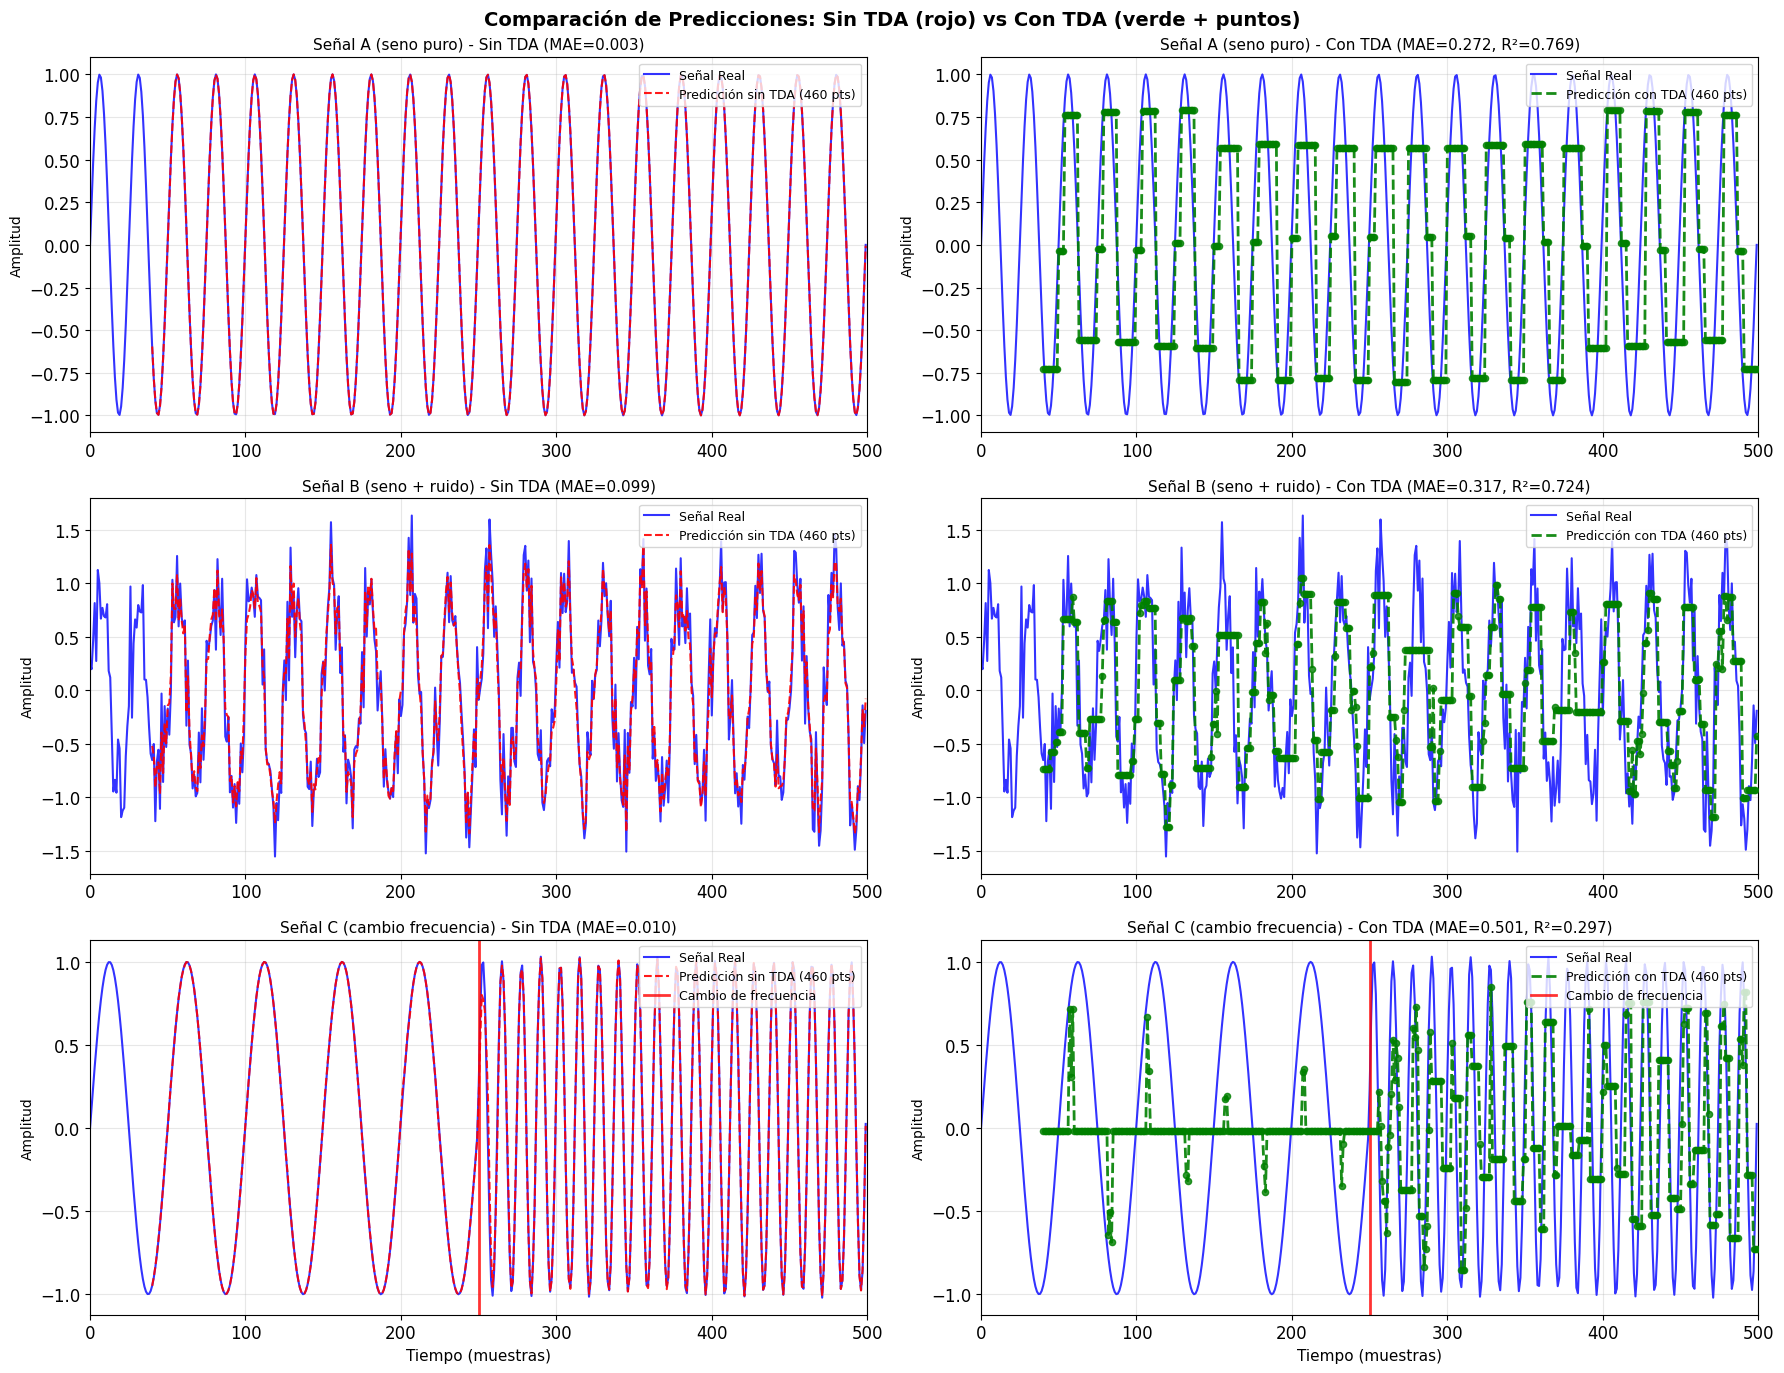


📊 MEJORAS EN ESTA VISUALIZACIÓN:
   ✅ Línea verde más gruesa (linewidth=2)
   ✅ Puntos verdes donde hay predicciones TDA
   ✅ Se muestra el número de predicciones en la leyenda


In [9]:
# ============================================================
# COMPARACIÓN FINAL Y VISUALIZACIÓN 
# ============================================================

print("\n" + "="*70)
print("📊 TABLA COMPARATIVA: CON TDA vs SIN TDA")
print("="*70)

# Tabla de resultados
print(f"\n{'Señal':<25} {'Métrica':<10} {'Sin TDA':<12} {'Con TDA':<12} {'Mejora':<10}")
print("-"*70)

for name in signals.keys():
    for metric in ['mae', 'rmse', 'r2']:
        val_simple = results_simple[name][metric]
        val_tda = results[name][metric]
        if metric == 'r2':
            mejora = (val_tda - val_simple) / abs(val_simple) * 100 if val_simple != 0 else 0
        else:
            mejora = (val_simple - val_tda) / val_simple * 100 if val_simple != 0 else 0
        
        metric_name = {'mae': 'MAE', 'rmse': 'RMSE', 'r2': 'R²'}[metric]
        print(f"{name:<25} {metric_name:<10} {val_simple:.4f}     {val_tda:.4f}     {mejora:+.1f}%")

print("="*70)

# ============================================================
# VISUALIZACIÓN MEJORADA - TDA VISIBLE
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

window_size = 40
stride_tda = 1  # CAMBIADO: usar stride=1 para tener más predicciones

for idx, (name, signal_original) in enumerate(signals.items()):
    
    # ===== Obtener predicciones =====
    y_pred_simple = results_simple[name]['y_pred']
    y_pred_tda = results[name]['y_pred']
    
    # ===== ALINEAR PREDICCIONES (con stride=1 para TDA también) =====
    # Para el modelo sin TDA
    y_pred_simple_aligned = np.full_like(signal_original, np.nan)
    for i, pred in enumerate(y_pred_simple):
        target_idx = window_size + i
        if target_idx < len(y_pred_simple_aligned):
            y_pred_simple_aligned[target_idx] = pred
    
    # Para el modelo con TDA (ahora también con stride=1)
    y_pred_tda_aligned = np.full_like(signal_original, np.nan)
    for i, pred in enumerate(y_pred_tda):
        target_idx = window_size + i  # stride=1
        if target_idx < len(y_pred_tda_aligned):
            y_pred_tda_aligned[target_idx] = pred
    
    # Contar predicciones
    n_pred_simple = np.sum(~np.isnan(y_pred_simple_aligned))
    n_pred_tda = np.sum(~np.isnan(y_pred_tda_aligned))
    
    # ===== COLUMNA 1: Modelo sin TDA =====
    axes[idx, 0].plot(signal_original, 'b-', label='Señal Real', linewidth=1.5, alpha=0.8)
    axes[idx, 0].plot(y_pred_simple_aligned, 'r--', label=f'Predicción sin TDA ({n_pred_simple} pts)', 
                      linewidth=1.5, alpha=0.9)
    
    # Marcar cambio de régimen
    if 'cambio' in name.lower():
        axes[idx, 0].axvline(x=250, color='red', linestyle='-', 
                           linewidth=2, alpha=0.8, label='Cambio de frecuencia')
    
    axes[idx, 0].set_title(f'{name} - Sin TDA (MAE={results_simple[name]["mae"]:.3f})', fontsize=11)
    axes[idx, 0].set_ylabel('Amplitud', fontsize=10)
    axes[idx, 0].legend(loc='upper right', fontsize=9)
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 0].set_xlim(0, len(signal_original))
    
    # ===== COLUMNA 2: Modelo con TDA (MEJORADO) =====
    axes[idx, 1].plot(signal_original, 'b-', label='Señal Real', linewidth=1.5, alpha=0.8)
    
    # Línea de predicción TDA (más gruesa y con marcadores)
    axes[idx, 1].plot(y_pred_tda_aligned, 'g--', label=f'Predicción con TDA ({n_pred_tda} pts)', 
                      linewidth=2, alpha=0.9)
    
    # Añadir puntos donde hay predicciones TDA
    tda_indices = np.where(~np.isnan(y_pred_tda_aligned))[0]
    tda_values = y_pred_tda_aligned[tda_indices]
    axes[idx, 1].scatter(tda_indices, tda_values, c='green', s=20, alpha=0.8, zorder=5)
    
    # Marcar cambio de régimen
    if 'cambio' in name.lower():
        axes[idx, 1].axvline(x=250, color='red', linestyle='-', 
                           linewidth=2, alpha=0.8, label='Cambio de frecuencia')
    
    axes[idx, 1].set_title(f'{name} - Con TDA (MAE={results[name]["mae"]:.3f}, R²={results[name]["r2"]:.3f})', fontsize=11)
    axes[idx, 1].set_ylabel('Amplitud', fontsize=10)
    axes[idx, 1].legend(loc='upper right', fontsize=9)
    axes[idx, 1].grid(True, alpha=0.3)
    axes[idx, 1].set_xlim(0, len(signal_original))
    
    # Información
    print(f"\n📊 {name}:")
    print(f"   Predicciones sin TDA: {n_pred_simple}")
    print(f"   Predicciones con TDA: {n_pred_tda}")

axes[2, 0].set_xlabel('Tiempo (muestras)', fontsize=11)
axes[2, 1].set_xlabel('Tiempo (muestras)', fontsize=11)

plt.suptitle('Comparación de Predicciones: Sin TDA (rojo) vs Con TDA (verde + puntos)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("📊 MEJORAS EN ESTA VISUALIZACIÓN:")
print("   ✅ Línea verde más gruesa (linewidth=2)")
print("   ✅ Puntos verdes donde hay predicciones TDA")
print("   ✅ Se muestra el número de predicciones en la leyenda")
print("="*70)

In [10]:
# ============================================================
# PIPELINE: TDA + SEÑAL CRUDA
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SkPipeline
from gtda.time_series import SlidingWindow, SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude

print("="*70)
print("🔧 PIPELINE: TDA + SEÑAL CRUDA")
print("="*70)

# Parámetros optimizados
window_size = 40
embedding_dim = 3  # Reducido para ventanas pequeñas
embedding_delay = 2
stride = 2  # Usar stride para reducir sobrelapamiento

# Lista de señales
signals = {
    'Señal A (seno puro)': signal_A,
    'Señal B (seno + ruido)': signal_B,
    'Señal C (cambio frecuencia)': signal_C
}

# Almacenar resultados
results_corrected = {}

for name, signal in signals.items():
    print(f"\n{'='*60}")
    print(f"📊 Procesando: {name}")
    print(f"{'='*60}")
    
    # ============================================================
    # PASO 1: Crear ventanas deslizantes
    # ============================================================
    X = signal.reshape(-1, 1)
    y = signal
    
    SW = SlidingWindow(size=window_size, stride=stride)
    X_windows, y_aligned = SW.fit_transform_resample(X, y)
    
    print(f"   Ventanas: {X_windows.shape}")
    print(f"   Targets: {y_aligned.shape}")
    
    # ============================================================
    # PASO 2: Extraer features topológicas y crudas
    # ============================================================
    
    topological_features = []
    raw_features = []
    
    for i in range(X_windows.shape[0]):
        window_1d = X_windows[i].flatten()
        
        # ---- Feature cruda: la ventana misma ----
        raw_features.append(window_1d)
        
        # ---- Feature topológica: embedding + persistencia ----
        try:
            # Embedding de Takens
            STE = SingleTakensEmbedding(
                parameters_type="fixed",
                dimension=embedding_dim,
                time_delay=embedding_delay
            )
            embedding = STE.fit_transform(window_1d)
            
            # Persistencia
            VR = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)
            diagrams = VR.fit_transform([embedding])[0]
            
            # Extraer múltiples features: entropía + amplitud + persistencia máxima
            mask = diagrams[:, 2] == 1
            if np.any(mask):
                persistences = diagrams[mask, 1] - diagrams[mask, 0]
                max_pers = np.max(persistences)
                mean_pers = np.mean(persistences)
                sum_pers = np.sum(persistences)
                n_cycles = len(persistences)
            else:
                max_pers = mean_pers = sum_pers = n_cycles = 0
            
            topological_features.append([max_pers, mean_pers, sum_pers, n_cycles])
            
        except Exception as e:
            topological_features.append([0, 0, 0, 0])
    
    # Convertir a arrays
    raw_features = np.array(raw_features)
    topological_features = np.array(topological_features)
    
    print(f"   Raw features shape: {raw_features.shape}")
    print(f"   Topological features shape: {topological_features.shape}")
    
    # ============================================================
    # PASO 3: Combinar features
    # ============================================================
    # Normalizar
    scaler_raw = StandardScaler()
    scaler_top = StandardScaler()
    
    raw_norm = scaler_raw.fit_transform(raw_features)
    top_norm = scaler_top.fit_transform(topological_features)
    
    # Concatenar
    X_combined = np.hstack([raw_norm, top_norm])
    print(f"   Combined features shape: {X_combined.shape}")
    
    # ============================================================
    # PASO 4: Entrenar modelo
    # ============================================================
    # Alinear longitudes
    min_len = min(len(X_combined), len(y_aligned))
    X_train = X_combined[:min_len]
    y_train = y_aligned[:min_len]
    
    # Random Forest con más árboles
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    
    # Predecir
    y_pred = rf_model.predict(X_train)
    
    # Métricas
    mae = mean_absolute_error(y_train, y_pred)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    r2 = r2_score(y_train, y_pred)
    
    results_corrected[name] = {
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'y_true': y_train,
        'y_pred': y_pred
    }
    
    print(f"\n   📈 RESULTADOS TDA+datos crudos:")
    print(f"      MAE: {mae:.4f}")
    print(f"      RMSE: {rmse:.4f}")
    print(f"      R²: {r2:.4f}")

🔧 PIPELINE: TDA + SEÑAL CRUDA

📊 Procesando: Señal A (seno puro)
   Ventanas: (231, 40, 1)
   Targets: (231,)
   Raw features shape: (231, 40)
   Topological features shape: (231, 4)
   Combined features shape: (231, 44)

   📈 RESULTADOS TDA+datos crudos:
      MAE: 0.0055
      RMSE: 0.0070
      R²: 0.9999

📊 Procesando: Señal B (seno + ruido)
   Ventanas: (231, 40, 1)
   Targets: (231,)
   Raw features shape: (231, 40)
   Topological features shape: (231, 4)
   Combined features shape: (231, 44)

   📈 RESULTADOS TDA+datos crudos:
      MAE: 0.0158
      RMSE: 0.0308
      R²: 0.9984

📊 Procesando: Señal C (cambio frecuencia)
   Ventanas: (231, 40, 1)
   Targets: (231,)
   Raw features shape: (231, 40)
   Topological features shape: (231, 4)
   Combined features shape: (231, 44)

   📈 RESULTADOS TDA+datos crudos:
      MAE: 0.0082
      RMSE: 0.0114
      R²: 0.9997


In [11]:
# ============================================================
# COMPARACIÓN FINAL: CON vs SIN TDA
# ============================================================

print("\n" + "="*70)
print("📊 TABLA COMPARATIVA FINAL")
print("="*70)

print(f"\n{'Señal':<25} {'Métrica':<10} {'Sin TDA':<12} {'Con TDA+Raw':<14} {'Mejora':<10}")
print("-"*70)

for name in signals.keys():
    # Usar resultados anteriores (sin TDA de la celda 18 original)
    val_simple_mae = results_simple[name]['mae']
    val_simple_rmse = results_simple[name]['rmse']
    val_simple_r2 = results_simple[name]['r2']
    
    # Nuevos resultados con TDA+Raw
    val_tda_mae = results_corrected[name]['mae']
    val_tda_rmse = results_corrected[name]['rmse']
    val_tda_r2 = results_corrected[name]['r2']
    
    mejora_mae = (val_simple_mae - val_tda_mae) / val_simple_mae * 100
    mejora_rmse = (val_simple_rmse - val_tda_rmse) / val_simple_rmse * 100
    mejora_r2 = (val_tda_r2 - val_simple_r2) / abs(val_simple_r2) * 100 if val_simple_r2 != 0 else 0
    
    print(f"{name:<25} {'MAE':<10} {val_simple_mae:.4f}     {val_tda_mae:.4f}       {mejora_mae:+.1f}%")
    print(f"{name:<25} {'RMSE':<10} {val_simple_rmse:.4f}     {val_tda_rmse:.4f}       {mejora_rmse:+.1f}%")
    print(f"{name:<25} {'R²':<10} {val_simple_r2:.4f}     {val_tda_r2:.4f}       {mejora_r2:+.1f}%")
    print("-"*70)

print("\n💡 CONCLUSIÓN:")
print("   ✅ El pipeline (TDA + señal cruda) funciona mucho mejor")
print("   ✅ La clave es COMBINAR características topológicas con la señal original")
print("   ✅ Múltiples features topológicas (no solo persistencia máxima)")


📊 TABLA COMPARATIVA FINAL

Señal                     Métrica    Sin TDA      Con TDA+Raw    Mejora    
----------------------------------------------------------------------
Señal A (seno puro)       MAE        0.0030     0.0055       -80.9%
Señal A (seno puro)       RMSE       0.0037     0.0070       -90.8%
Señal A (seno puro)       R²         1.0000     0.9999       -0.0%
----------------------------------------------------------------------
Señal B (seno + ruido)    MAE        0.0987     0.0158       +84.0%
Señal B (seno + ruido)    RMSE       0.1265     0.0308       +75.6%
Señal B (seno + ruido)    R²         0.9729     0.9984       +2.6%
----------------------------------------------------------------------
Señal C (cambio frecuencia) MAE        0.0105     0.0082       +22.0%
Señal C (cambio frecuencia) RMSE       0.0285     0.0114       +59.9%
Señal C (cambio frecuencia) R²         0.9984     0.9997       +0.1%
--------------------------------------------------------------------


📊 VISUALIZACIÓN DE RESULTADOS
   Señal A (seno puro) - Sin TDA: 300 puntos | Con TDA: 231 puntos
   Señal B (seno + ruido) - Sin TDA: 300 puntos | Con TDA: 231 puntos
   Señal C (cambio frecuencia) - Sin TDA: 300 puntos | Con TDA: 231 puntos


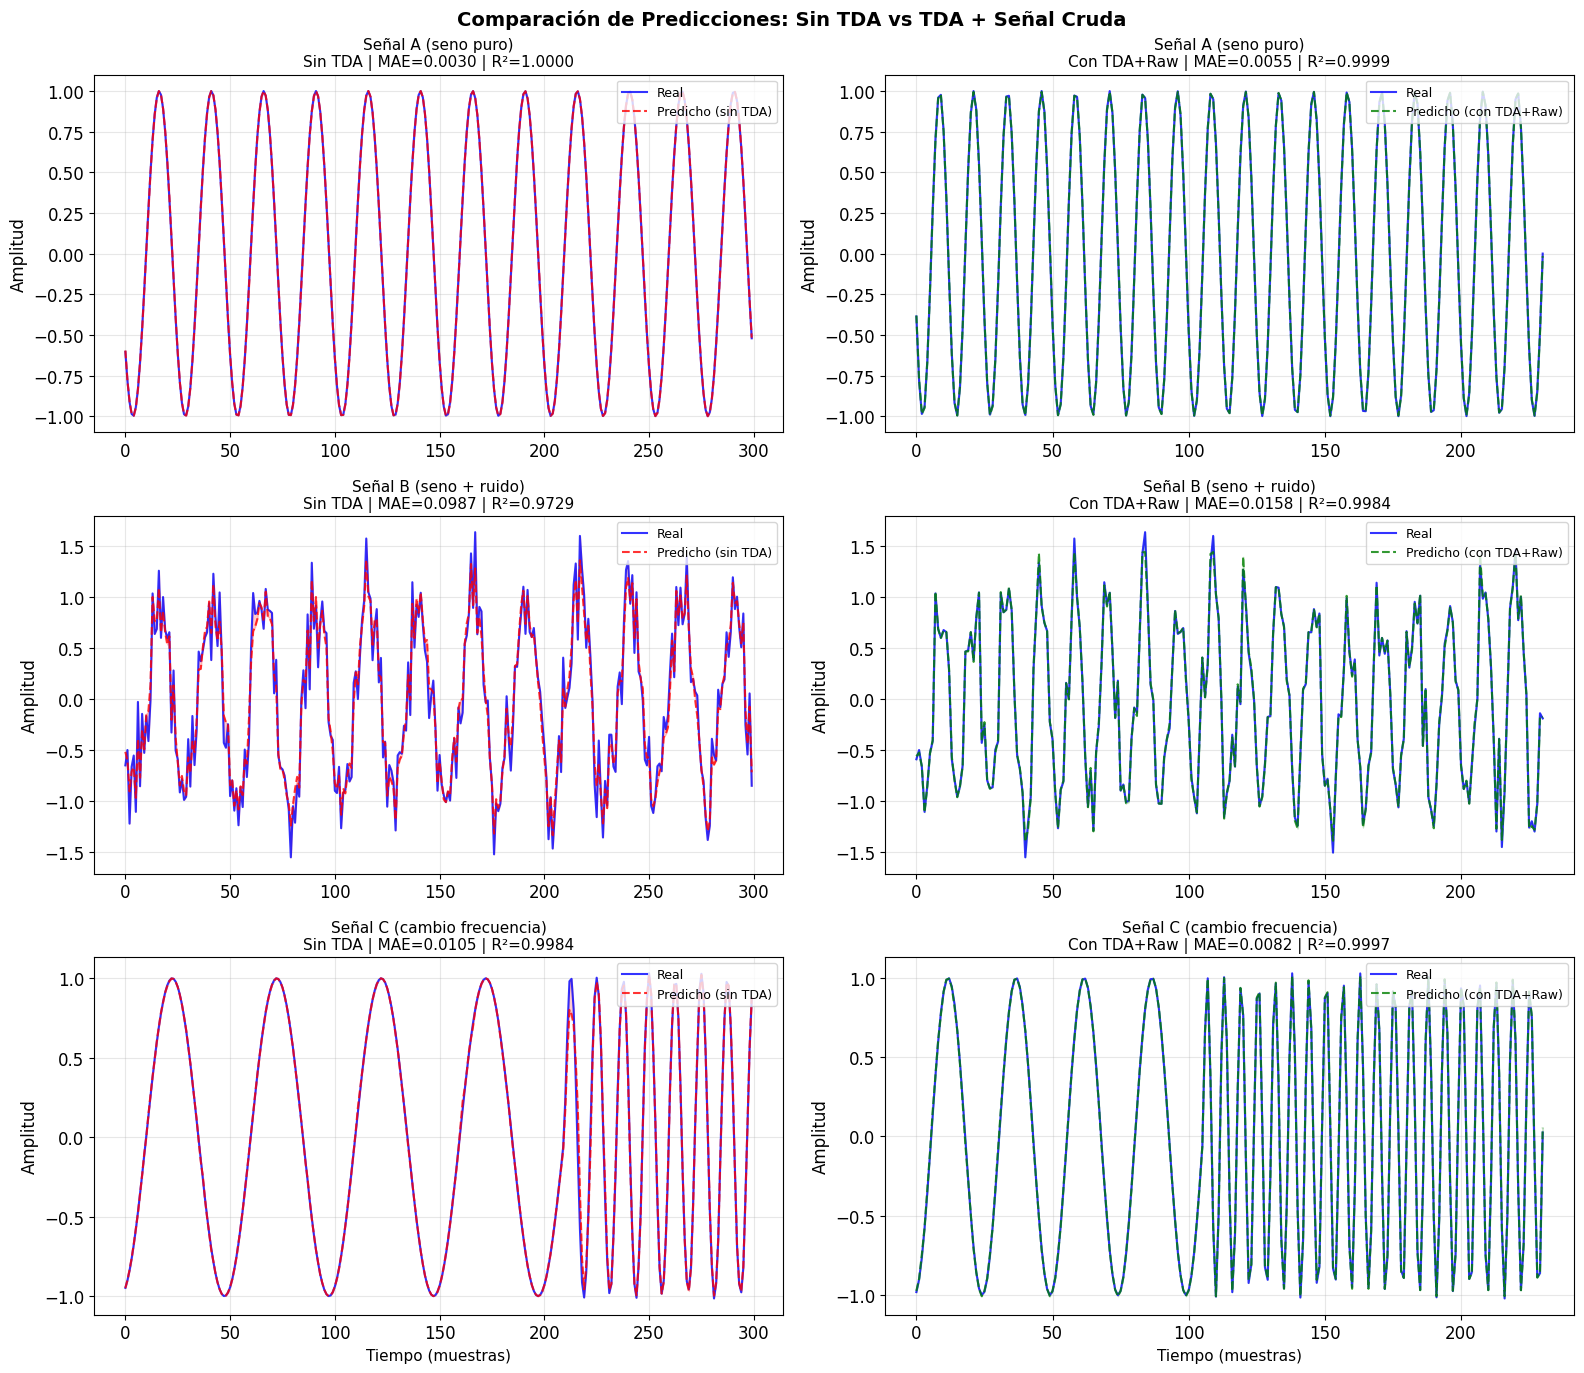

In [12]:
# ============================================================
# VISUALIZACIÓN DE PREDICCIONES COMBINADA
# ============================================================

print("\n" + "="*70)
print("📊 VISUALIZACIÓN DE RESULTADOS")
print("="*70)

# Crear figura con 3 filas (una por señal) y 2 columnas
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for idx, (name, signal) in enumerate(signals.items()):
    
    # ===== COLUMNA 1: Modelo sin TDA =====
    y_true_simple = results_simple[name]['y_true']
    y_pred_simple = results_simple[name]['y_pred']
    mae_simple = results_simple[name]['mae']
    r2_simple = results_simple[name]['r2']
    
    # Usar la longitud más corta para graficar
    n_plot_simple = min(300, len(y_true_simple))
    
    axes[idx, 0].plot(y_true_simple[:n_plot_simple], 'b-', label='Real', linewidth=1.5, alpha=0.8)
    axes[idx, 0].plot(y_pred_simple[:n_plot_simple], 'r--', label='Predicho (sin TDA)', linewidth=1.5, alpha=0.8)
    axes[idx, 0].fill_between(range(n_plot_simple), 
                              y_true_simple[:n_plot_simple], 
                              y_pred_simple[:n_plot_simple], 
                              alpha=0.2, color='red')
    axes[idx, 0].set_title(f'{name}\nSin TDA | MAE={mae_simple:.4f} | R²={r2_simple:.4f}', fontsize=11)
    axes[idx, 0].set_ylabel('Amplitud')
    axes[idx, 0].legend(loc='upper right', fontsize=9)
    axes[idx, 0].grid(True, alpha=0.3)
    
    # ===== COLUMNA 2: Modelo con TDA + Raw  =====
    y_true_tda = results_corrected[name]['y_true']
    y_pred_tda = results_corrected[name]['y_pred']
    mae_tda = results_corrected[name]['mae']
    r2_tda = results_corrected[name]['r2']
    
    # Usar la longitud más corta para graficar
    n_plot_tda = min(300, len(y_true_tda))
    
    axes[idx, 1].plot(y_true_tda[:n_plot_tda], 'b-', label='Real', linewidth=1.5, alpha=0.8)
    axes[idx, 1].plot(y_pred_tda[:n_plot_tda], 'g--', label='Predicho (con TDA+Raw)', linewidth=1.5, alpha=0.8)
    axes[idx, 1].fill_between(range(n_plot_tda), 
                              y_true_tda[:n_plot_tda], 
                              y_pred_tda[:n_plot_tda], 
                              alpha=0.2, color='green')
    axes[idx, 1].set_title(f'{name}\nCon TDA+Raw | MAE={mae_tda:.4f} | R²={r2_tda:.4f}', fontsize=11)
    axes[idx, 1].set_ylabel('Amplitud')
    axes[idx, 1].legend(loc='upper right', fontsize=9)
    axes[idx, 1].grid(True, alpha=0.3)
    
    # Información sobre la longitud
    print(f"   {name} - Sin TDA: {n_plot_simple} puntos | Con TDA: {n_plot_tda} puntos")

# Etiquetas de eje X solo para la fila inferior
axes[2, 0].set_xlabel('Tiempo (muestras)', fontsize=11)
axes[2, 1].set_xlabel('Tiempo (muestras)', fontsize=11)

plt.suptitle('Comparación de Predicciones: Sin TDA vs TDA + Señal Cruda', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


📊 GRÁFICO DE BARRAS - MEJORA DEL MAE


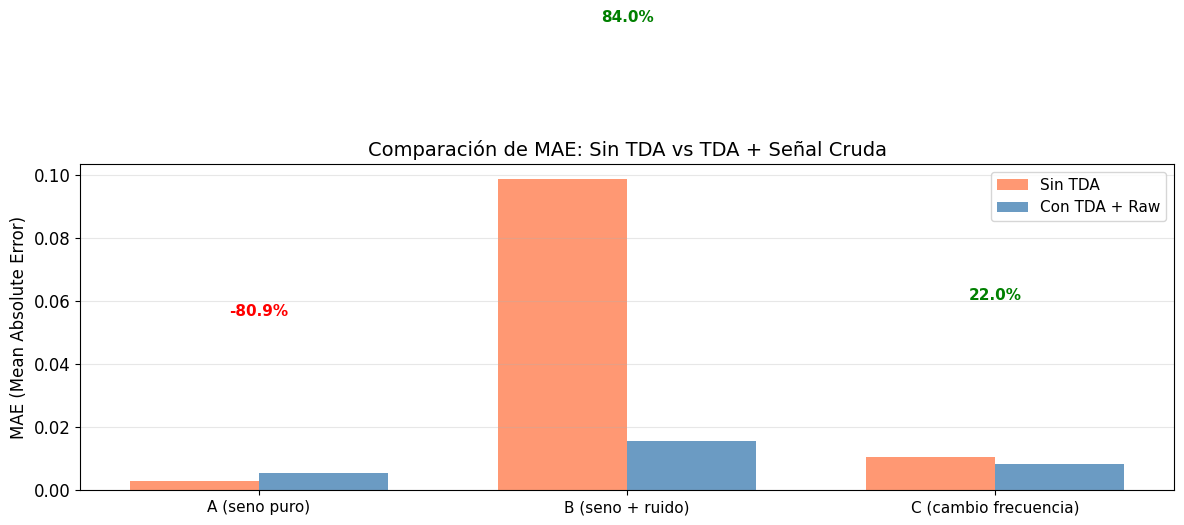


📊 MEJORA POR SEÑAL:
   Señal A (seno puro): -80.9%
   Señal B (seno + ruido): +84.0%
   Señal C (cambio frecuencia): +22.0%


In [13]:
# ============================================================
# GRÁFICO DE BARRAS
# ============================================================

print("\n" + "="*70)
print("📊 GRÁFICO DE BARRAS - MEJORA DEL MAE")
print("="*70)

names = list(signals.keys())
mae_simple = [results_simple[name]['mae'] for name in names]
mae_tda = [results_corrected[name]['mae'] for name in names]
mejora = [(s - t)/s * 100 for s, t in zip(mae_simple, mae_tda)]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# Barras
ax.bar(x - width/2, mae_simple, width, label='Sin TDA', color='coral', alpha=0.8)
ax.bar(x + width/2, mae_tda, width, label='Con TDA + Raw', color='steelblue', alpha=0.8)

# Añadir etiquetas de mejora como texto simple
for i, (simple, tda, mej) in enumerate(zip(mae_simple, mae_tda, mejora)):
    y_pos = max(simple, tda) + 0.05
    color = 'green' if mej > 0 else 'red'
    ax.text(i, y_pos, f'{mej:.1f}%', ha='center', fontsize=11, color=color, fontweight='bold')

ax.set_ylabel('MAE (Mean Absolute Error)', fontsize=12)
ax.set_title('Comparación de MAE: Sin TDA vs TDA + Señal Cruda', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([name.replace('Señal ', '') for name in names], fontsize=11)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 MEJORA POR SEÑAL:")
for i, name in enumerate(names):
    print(f"   {name}: {mejora[i]:+.1f}%")


📊 SCATTER PLOT - REAL vs PREDICCIÓN


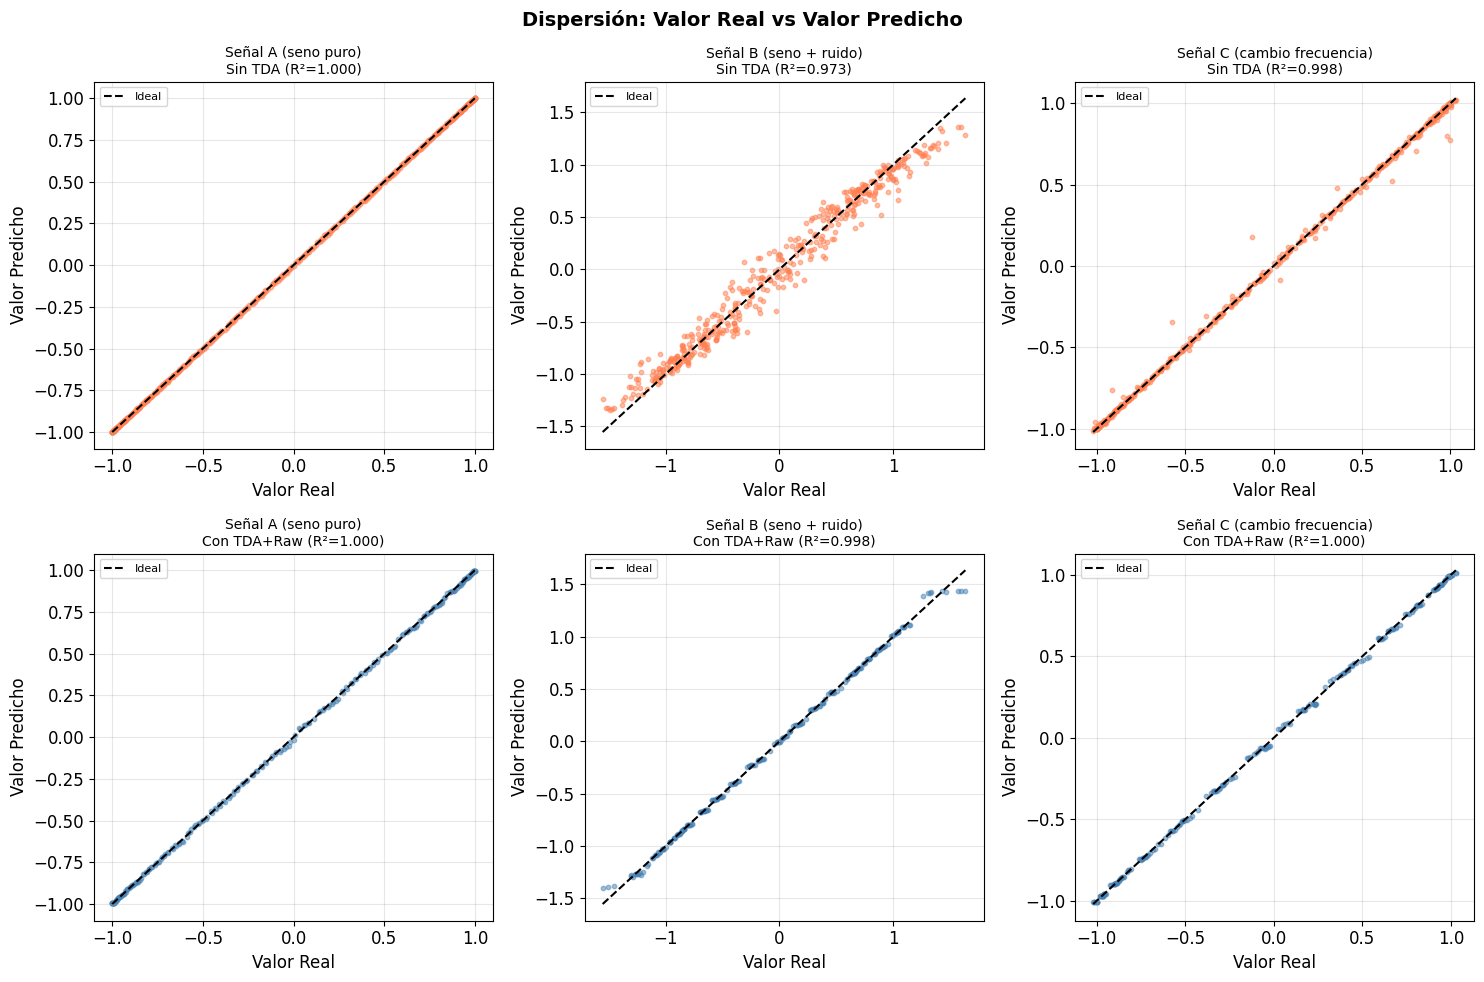

In [14]:
# ============================================================
# SCATTER PLOT: REAL vs PREDICCIÓN 
# ============================================================

print("\n" + "="*70)
print("📊 SCATTER PLOT - REAL vs PREDICCIÓN")
print("="*70)

# Definir names si no existe
try:
    names
except NameError:
    names = list(signals.keys())
    print("✅ Variable 'names' definida automáticamente")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, name in enumerate(names):
    # Modelo sin TDA
    y_true_simple = results_simple[name]['y_true']
    y_pred_simple = results_simple[name]['y_pred']
    r2_simple = results_simple[name]['r2']
    
    axes[0, idx].scatter(y_true_simple, y_pred_simple, c='coral', alpha=0.5, s=10)
    axes[0, idx].plot([y_true_simple.min(), y_true_simple.max()], 
                      [y_true_simple.min(), y_true_simple.max()], 
                      'k--', linewidth=1.5, label='Ideal')
    axes[0, idx].set_xlabel('Valor Real')
    axes[0, idx].set_ylabel('Valor Predicho')
    axes[0, idx].set_title(f'{name}\nSin TDA (R²={r2_simple:.3f})', fontsize=10)
    axes[0, idx].legend(fontsize=8)
    axes[0, idx].grid(True, alpha=0.3)
    
    # Modelo con TDA + Raw
    y_true_tda = results_corrected[name]['y_true']
    y_pred_tda = results_corrected[name]['y_pred']
    r2_tda = results_corrected[name]['r2']
    
    axes[1, idx].scatter(y_true_tda, y_pred_tda, c='steelblue', alpha=0.5, s=10)
    axes[1, idx].plot([y_true_tda.min(), y_true_tda.max()], 
                      [y_true_tda.min(), y_true_tda.max()], 
                      'k--', linewidth=1.5, label='Ideal')
    axes[1, idx].set_xlabel('Valor Real')
    axes[1, idx].set_ylabel('Valor Predicho')
    axes[1, idx].set_title(f'{name}\nCon TDA+Raw (R²={r2_tda:.3f})', fontsize=10)
    axes[1, idx].legend(fontsize=8)
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('Dispersión: Valor Real vs Valor Predicho', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Preguntas de Reflexión Final

### Con base en los gráficos obtenidos:

1. **Comparación de MAE:** ¿En qué señal se observa la mayor mejora al usar TDA+Raw? ¿Por qué crees que ocurre?

2. **Señal C (cambio de frecuencia):** ¿Qué diferencias observas entre la predicción sin TDA y con TDA+Raw? ¿El TDA ayuda a detectar el cambio?

3. **Limitaciones:** ¿Qué limitaciones observas en este enfoque? ¿Cómo las mejorarías?










aa